# Healthcare Utilization — Analytical Dashboard

This notebook is a **pure analytics dashboard** over the MIMIC-FHIR gold layer.
It demonstrates two key architectural properties:

1. **Decoupled data access** — all data is fetched via the project's REST API (`/utilization`), not from the database directly. The notebook has zero SQL and zero DuckDB imports.
2. **Reusable analytics module** — every visualization comes from `src.utilization.analytics`, a standalone Python module that accepts DataFrames and returns figures.

Together these prove that an analytic study can be built **without coupling to the pipeline implementation**, and can be reproduced against any source the API exposes (MIMIC-IV, Synthea, or future datasets).

In [1]:
import sys, subprocess, time, signal
import httpx
import pandas as pd

sys.path.insert(0, "..")
from src.utilization.analytics import (
    source_comparison_table,
    plot_encounter_class_breakdown,
    plot_los_distribution,
    plot_demographic_summary,
    plot_utilization_heatmap,
    plot_patient_timeline,
)

API_BASE = "http://127.0.0.1:8000"

## 0. Start the API

Launch the FastAPI server as a background process. The cell is idempotent — if the API is already running it skips the launch.

In [2]:
def _api_running() -> bool:
    try:
        return httpx.get(f"{API_BASE}/", timeout=2).status_code == 200
    except httpx.ConnectError:
        return False

if _api_running():
    print("API already running.")
    _server = None
else:
    _server = subprocess.Popen(
        ["uvicorn", "api.main:app", "--host", "127.0.0.1", "--port", "8000"],
        cwd="..",
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    for _ in range(20):
        time.sleep(0.5)
        if _api_running():
            break
    print("API started — PID", _server.pid)

httpx.get(f"{API_BASE}/").json()

API already running.


{'status': 'ok', 'docs': '/docs'}

## 1. Gold Layer Overview — Source Comparison

Fetch aggregate statistics from `GET /utilization/stats` and compare MIMIC-IV vs Synthea across key metrics.

In [3]:
stats = pd.DataFrame(httpx.get(f"{API_BASE}/utilization/stats").json())
source_comparison_table(stats)

,encounters,avg_los_hrs,avg_age,avg_enc_12m,avg_chronic
source,,,,,
mimic-iv,594054,44.0,55.5,2.6,0.0
synthea,182,10.9,35.9,6.5,0.0


## 2. Encounter Class Breakdown

Volume of encounters by class (EMER, OBSENC, ACUTE, AMB, SS) for each data source.

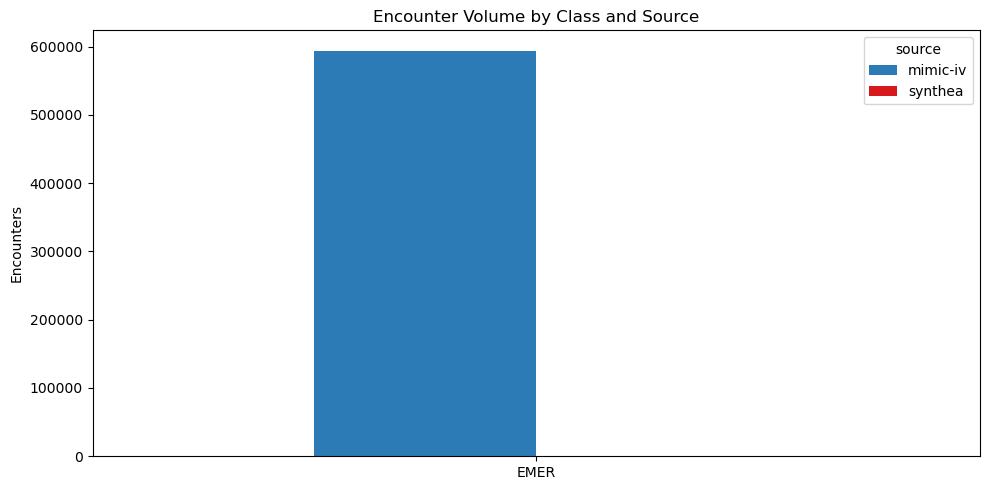

In [4]:
plot_encounter_class_breakdown(stats);

## 3. Fetch Record-Level Data

Pull a sample of records from each source to power the remaining visualizations.

In [5]:
mimic = pd.DataFrame(httpx.get(f"{API_BASE}/utilization", params={"source": "mimic-iv", "limit": 500}).json())
synthea = pd.DataFrame(httpx.get(f"{API_BASE}/utilization", params={"source": "synthea", "limit": 500}).json())
records = pd.concat([mimic, synthea], ignore_index=True)
print(f"Fetched {len(mimic)} MIMIC-IV + {len(synthea)} Synthea records via API")
records.head(3)

Fetched 500 MIMIC-IV + 182 Synthea records via API


,encounter_id,source,patient_id,encounter_class,period_start,period_end,los_hours,gender,birth_date,age_at_visit,...,ed_visits_12m,inpatient_12m,ambulatory_12m,wellness_12m,earliest_prior_encounter,most_recent_prior_encounter,total_conditions,chronic_conditions,encounter_diagnoses,distinct_diagnosis_codes
0,2636d4c3-9ccf-5fca-96b4-a46b36e56aa2,mimic-iv,a70592fc-9a8c-5de8-ba9c-960063f2f132,EMER,2212-04-05T23:23:00,2212-04-06T14:20:00,14.950000,female,2135-04-09T00:00:00,77.0,...,9,0,0,0,2211-03-27T10:30:00,2212-01-28T12:08:00,3,0,3,3
1,c4f49fa6-8a6a-5c7a-823b-d8364070799f,mimic-iv,a70592fc-9a8c-5de8-ba9c-960063f2f132,EMER,2212-01-28T12:08:00,2212-02-01T17:48:00,101.666667,female,2135-04-09T00:00:00,77.0,...,9,0,0,0,2211-03-27T10:30:00,2212-01-27T20:34:00,18,0,18,18
2,fa006684-cdac-5e5f-87dd-593905c3f741,mimic-iv,a70592fc-9a8c-5de8-ba9c-960063f2f132,EMER,2212-01-27T20:34:00,2212-01-28T13:17:00,16.716667,female,2135-04-09T00:00:00,77.0,...,8,0,0,0,2211-03-27T10:30:00,2212-01-19T15:43:00,2,0,2,2


## 4. Length of Stay Distribution

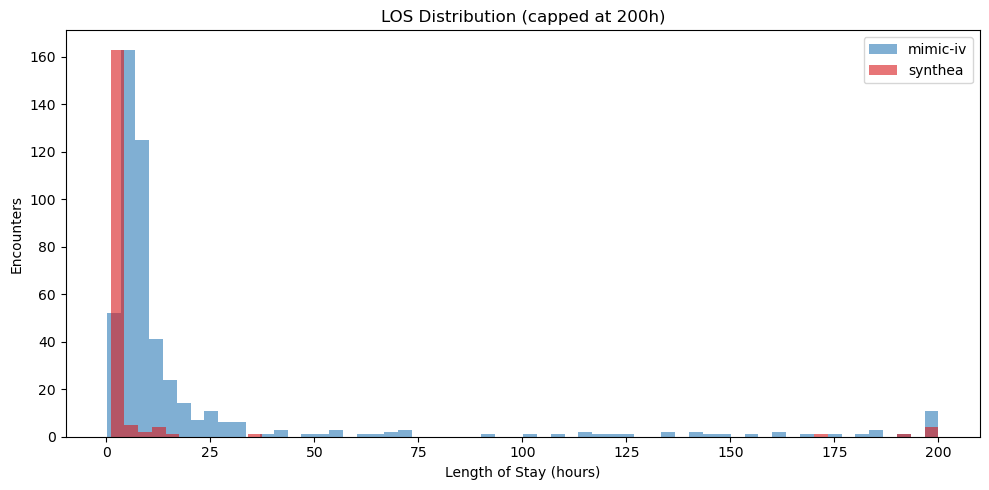

In [6]:
plot_los_distribution(records);

## 5. Demographics — Age & Gender

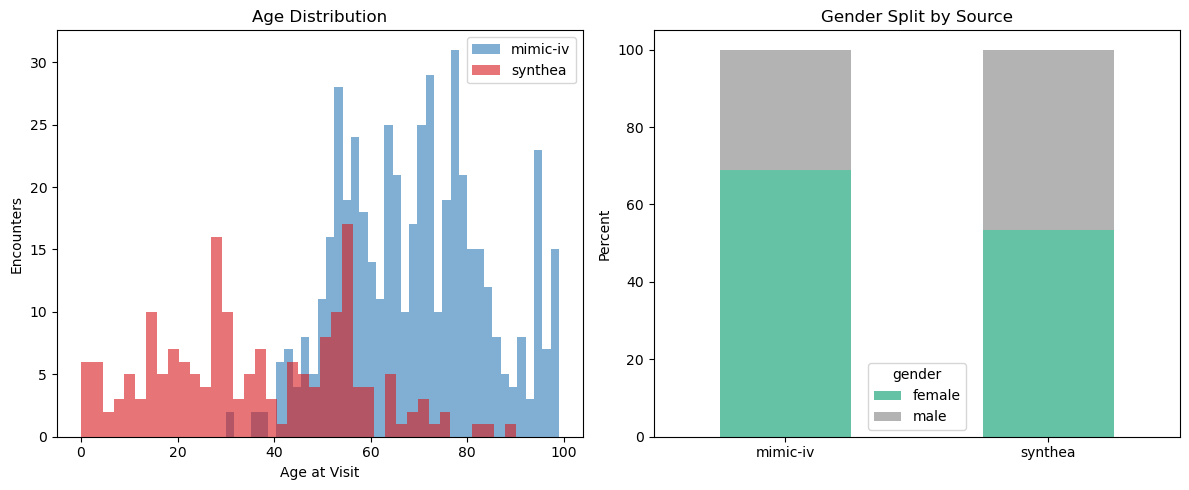

In [7]:
plot_demographic_summary(records);

## 6. Prior-Utilization Heatmap

Mean encounter counts across lookback windows (6m, 12m, 24m) and encounter types, grouped by source.

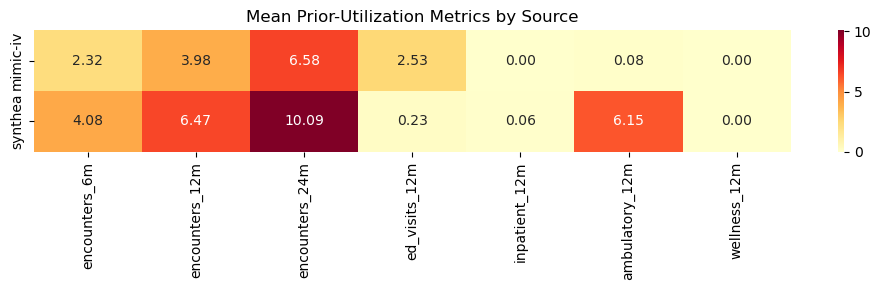

In [8]:
plot_utilization_heatmap(records);

## 7. Patient Deep Dive

Pick a patient from the fetched records and visualise their full encounter timeline via `GET /utilization/patient/{id}`.

In [9]:
# Choose a patient with multiple encounters
patient_counts = records.groupby("patient_id").size()
sample_patient = patient_counts.idxmax()

patient_data = pd.DataFrame(
    httpx.get(f"{API_BASE}/utilization/patient/{sample_patient}").json()
)
print(f"Patient {sample_patient} — {len(patient_data)} encounters")
patient_data[["encounter_class", "period_start", "period_end", "los_hours",
              "age_at_visit", "chronic_conditions", "encounter_diagnoses"]]

Patient eb604179-70ba-57d3-b946-9594f2bce625 — 61 encounters


,encounter_class,period_start,period_end,los_hours,age_at_visit,chronic_conditions,encounter_diagnoses
0,EMER,2210-07-20T03:56:00,2210-09-16T02:00:00,1390.066667,55.0,0,38
1,EMER,2210-07-19T17:54:00,2210-07-20T03:57:02,10.050556,55.0,0,5
2,EMER,2210-06-21T16:19:00,2210-06-21T23:51:00,7.533333,55.0,0,3
3,EMER,2210-05-25T17:59:00,2210-05-26T12:26:59,18.466389,55.0,0,1
4,EMER,2210-05-17T11:07:00,2210-05-18T00:38:00,13.516667,55.0,0,1
...,...,...,...,...,...,...,...
56,EMER,2205-02-21T10:17:00,2205-02-21T19:49:00,9.533333,50.0,0,1
57,EMER,2205-02-11T16:01:00,2205-02-18T17:34:00,169.550000,50.0,0,18
58,EMER,2205-02-11T12:30:00,2205-02-11T18:02:00,5.533333,50.0,0,2
59,EMER,2204-06-23T08:35:00,2204-06-23T10:29:56,1.915556,49.0,0,1


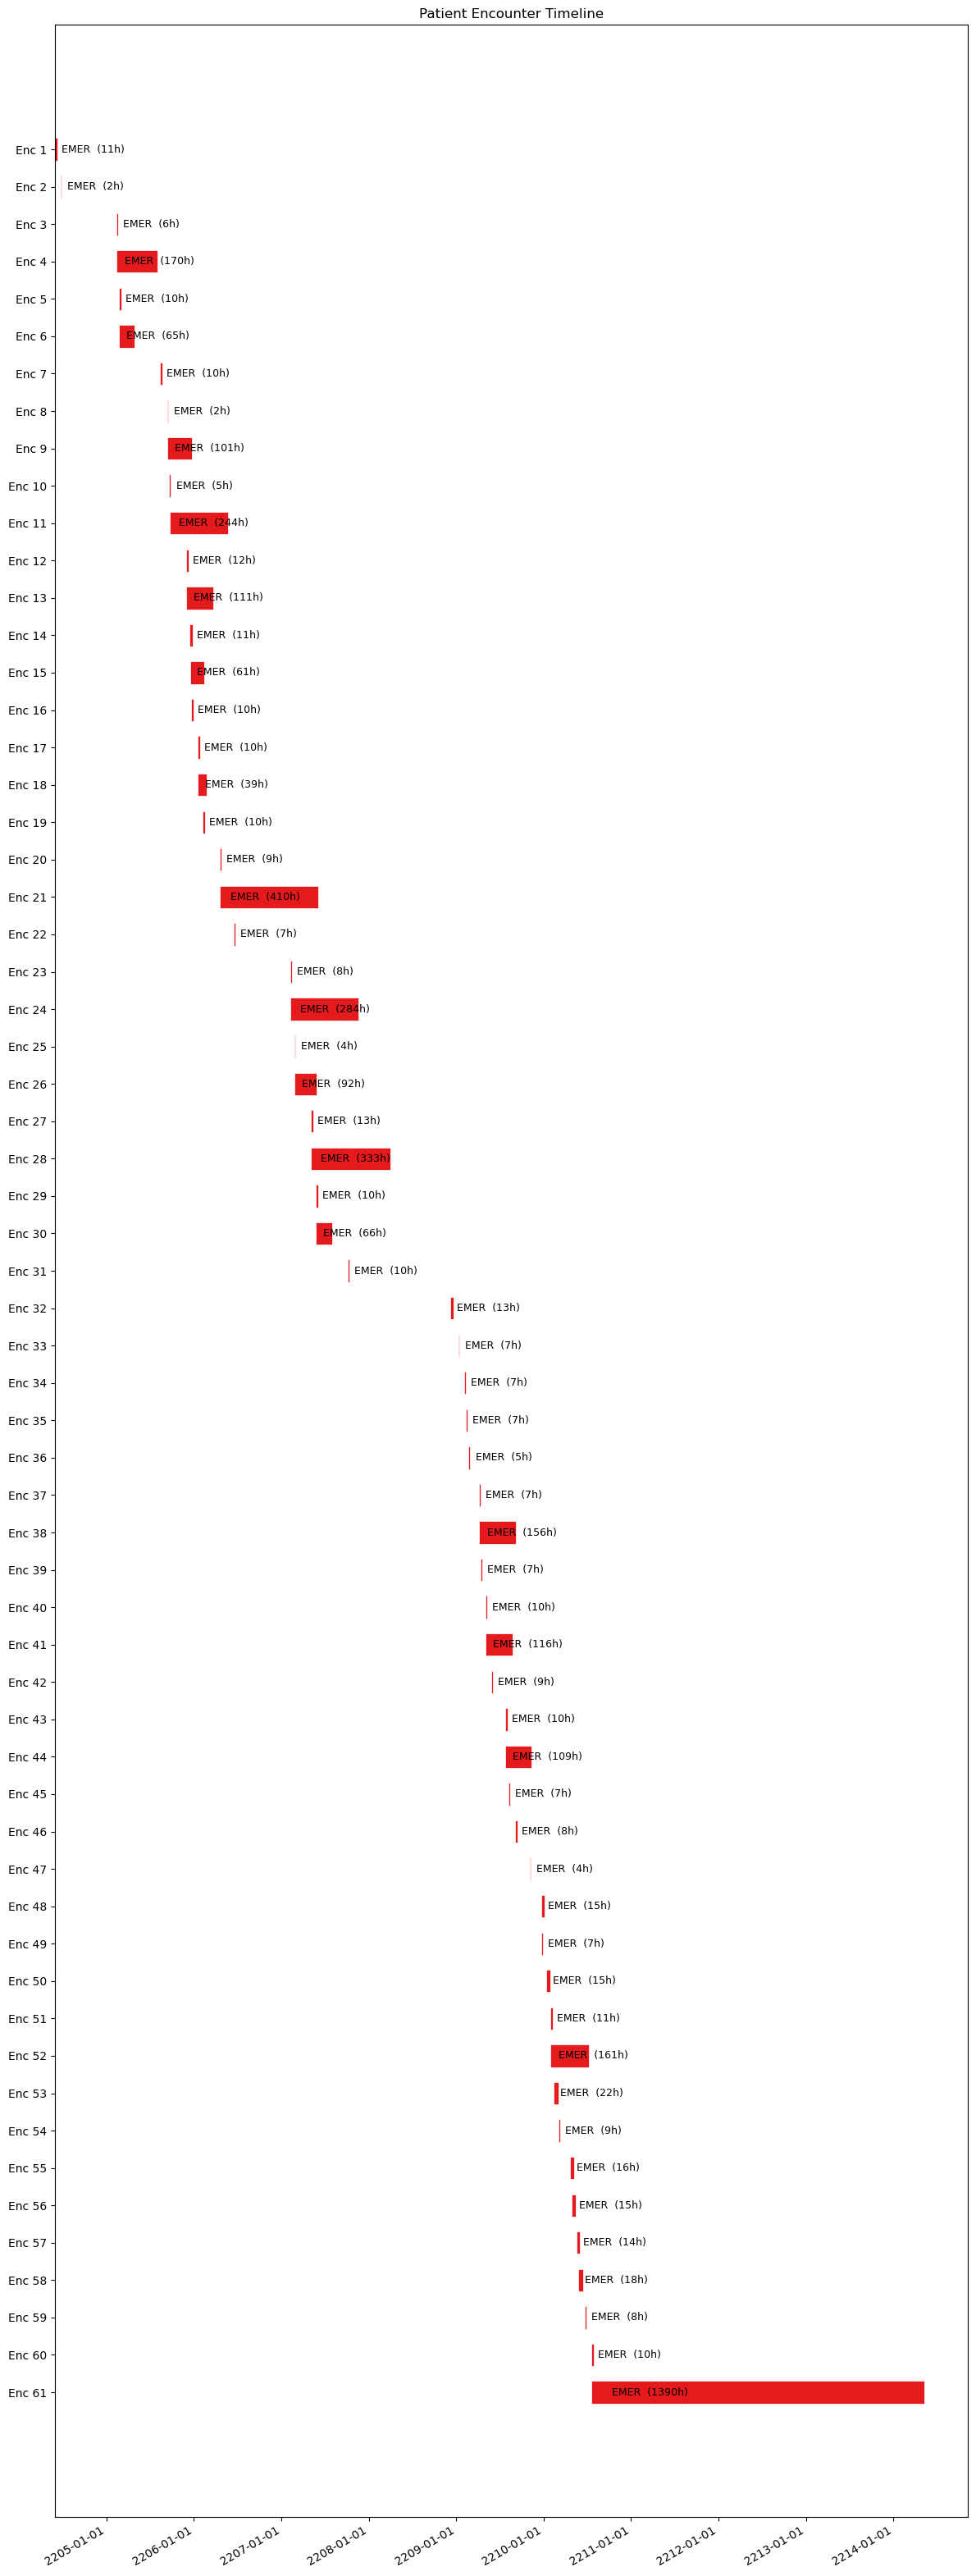

In [10]:
plot_patient_timeline(patient_data);

## 8. Teardown

Stop the background API server if we started it.

In [11]:
if _server is not None:
    _server.terminate()
    _server.wait(timeout=5)
    print("API server stopped.")
else:
    print("External API server left running.")

External API server left running.
